# 1. Generate and measure

Everything here is produced by the same C++ code as the `siggen` command line and the GUI, so the numbers match what you
see in the Measurements panel and what `siggen analyze` prints. The point of the notebook is to *compare the generator with
theory*: the usual first step before trusting a signal source.

In [1]:
import pathlib, sys
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # the python/ folder, when run from python/notebooks

import matplotlib.pyplot as plt
import numpy as np

import siggen

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
print("siggen library", siggen.version())

siggen library 0.5.0


## A 16-QAM signal at 20 dB SNR

`siggen.generate` takes the same options as the command line (`modulation`, `symbols`, `sps`, `snr_db`, `cfo_hz`, ...).
`samples` is a NumPy `complex64` array; `symbols` are the ideal transmitted points (unit mean energy).

In [2]:
tx = siggen.generate(modulation="16-QAM", symbols=512, sps=8, snr_db=20)
print(tx)
print(tx.power_statistics())
acc = tx.symbol_accuracy()
print(f"EVM {acc.evm_percent:.2f} %  ({acc.evm_db:.1f} dB), measured per-sample SNR {acc.sample_snr_db:.1f} dB (asked for 20)")

Signal(16-QAM, 4169 samples @ 8000 Hz)
{'mean_power': 0.12648933489492808, 'peak_power': 0.6113862661998439, 'papr_db': 6.842617698010977}
EVM 3.52 %  (-29.1 dB), measured per-sample SNR 20.0 dB (asked for 20)


## Waveform, constellation, eye and spectrum

`matched_symbols()` returns the matched-filter observations at the decision instants (what the Constellation tab shows),
`eye()` the overlaid traces of the Eye tab, and `psd()` the Welch estimate of the Spectrum tab.

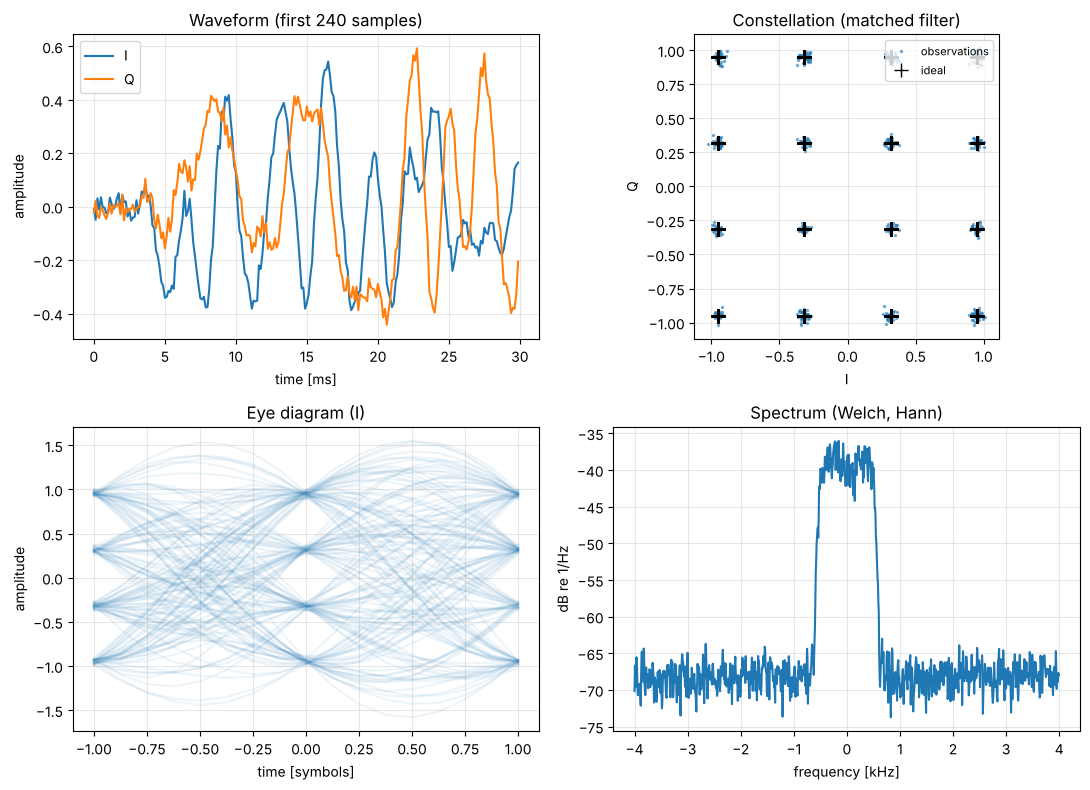

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

t = tx.time[:240] * 1e3
ax[0, 0].plot(t, tx.samples.real[:240], label="I")
ax[0, 0].plot(t, tx.samples.imag[:240], label="Q")
ax[0, 0].set(title="Waveform (first 240 samples)", xlabel="time [ms]", ylabel="amplitude"); ax[0, 0].legend()

obs, idx = tx.matched_symbols()
ax[0, 1].plot(obs.real, obs.imag, ".", ms=3, alpha=0.5, label="observations")
ax[0, 1].plot(tx.symbols.real, tx.symbols.imag, "k+", ms=10, label="ideal")
ax[0, 1].set(title="Constellation (matched filter)", xlabel="I", ylabel="Q", aspect="equal"); ax[0, 1].legend(loc="upper right", fontsize=8)

te, ei, eq = tx.eye(150)
ax[1, 0].plot(te, ei.T, color="C0", alpha=0.08)
ax[1, 0].set(title="Eye diagram (I)", xlabel="time [symbols]", ylabel="amplitude")

f, d = tx.psd()
ax[1, 1].plot(f / 1e3, 10 * np.log10(d))
ax[1, 1].set(title="Spectrum (Welch, Hann)", xlabel="frequency [kHz]", ylabel="dB re 1/Hz")
plt.tight_layout(); plt.show()

## EVM against SNR, compared with theory

With complex noise of power *N* added to a signal of power *S*, the per-sample SNR is *S/N*. The matched filter
averages `SPS` noisy samples per symbol, so the post-filter SNR is higher by `10 log10(SPS)`, and
`EVM = 10^(-SNR_post/20)` (RMS, relative to the RMS constellation radius).

At high SNR the measurement flattens: a truncated root-raised-cosine pulse leaves a little inter-symbol interference
(about -43 dB EVM for the default span), a floor no amount of SNR removes.

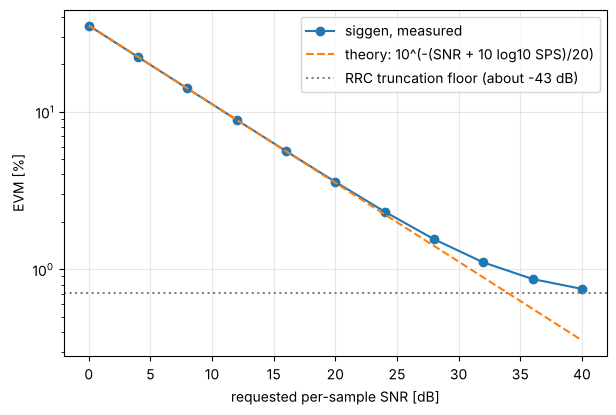

In [4]:
sps = 8
snrs = np.arange(0, 41, 4)
measured = [siggen.generate(modulation="16-QAM", symbols=2048, sps=sps, snr_db=s).symbol_accuracy().evm_percent for s in snrs]
theory = 100 * 10 ** (-(snrs + 10 * np.log10(sps)) / 20)

plt.figure(figsize=(7, 4.5))
plt.semilogy(snrs, measured, "o-", label="siggen, measured")
plt.semilogy(snrs, theory, "--", label="theory: 10^(-(SNR + 10 log10 SPS)/20)")
plt.axhline(100 * 10 ** (-43 / 20), color="gray", ls=":", label="RRC truncation floor (about -43 dB)")
plt.xlabel("requested per-sample SNR [dB]"); plt.ylabel("EVM [%]"); plt.legend(); plt.show()

## Windows trade resolution for leakage

The same tone seen through each Welch window: the rectangular window has the narrowest main lobe and the worst side
lobes; Blackman is the reverse.

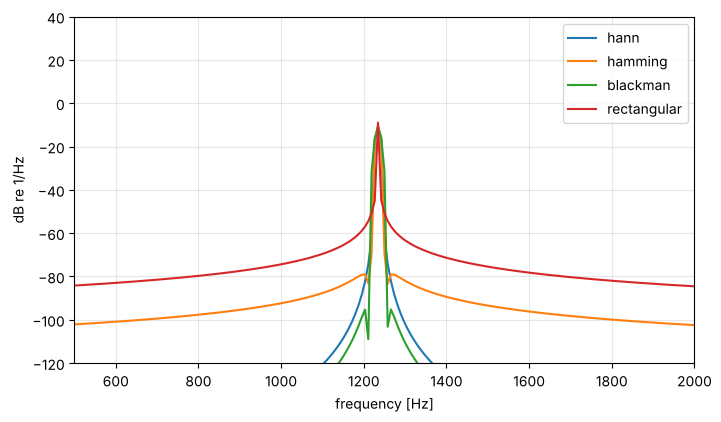

In [5]:
fs = 8000.0
tone = np.exp(2j * np.pi * 1234.5 * np.arange(16384) / fs).astype(np.complex64)
plt.figure(figsize=(8, 4.5))
for name in siggen.WINDOWS:
    f, d = siggen.psd(tone, fs, name)
    plt.plot(f, 10 * np.log10(d + 1e-30), label=name)
plt.xlim(500, 2000); plt.ylim(-120, 40); plt.xlabel("frequency [Hz]"); plt.ylabel("dB re 1/Hz"); plt.legend(); plt.show()